<a href="https://colab.research.google.com/github/HarshithaBoppudi/assignment-01-BITSoM_BA_2511750/blob/main/part4-vector-db/Embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
sentences = [
    "The batsman scored a century in the final match.",
    "The bowler delivered a perfect yorker.",
    "The cricket team celebrated their victory.",
    "I love experimenting with spices in cooking.",
    "The chef prepared a delicious pasta dish.",
    "Baking bread requires patience and precision.",
    "Cybersecurity protects systems from malicious attacks.",
    "Strong passwords are essential for online safety.",
    "Hackers often exploit software vulnerabilities.",
    "Data encryption ensures secure communication."
]

In [ ]:
!pip install sentence-transformers matplotlib seaborn

from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

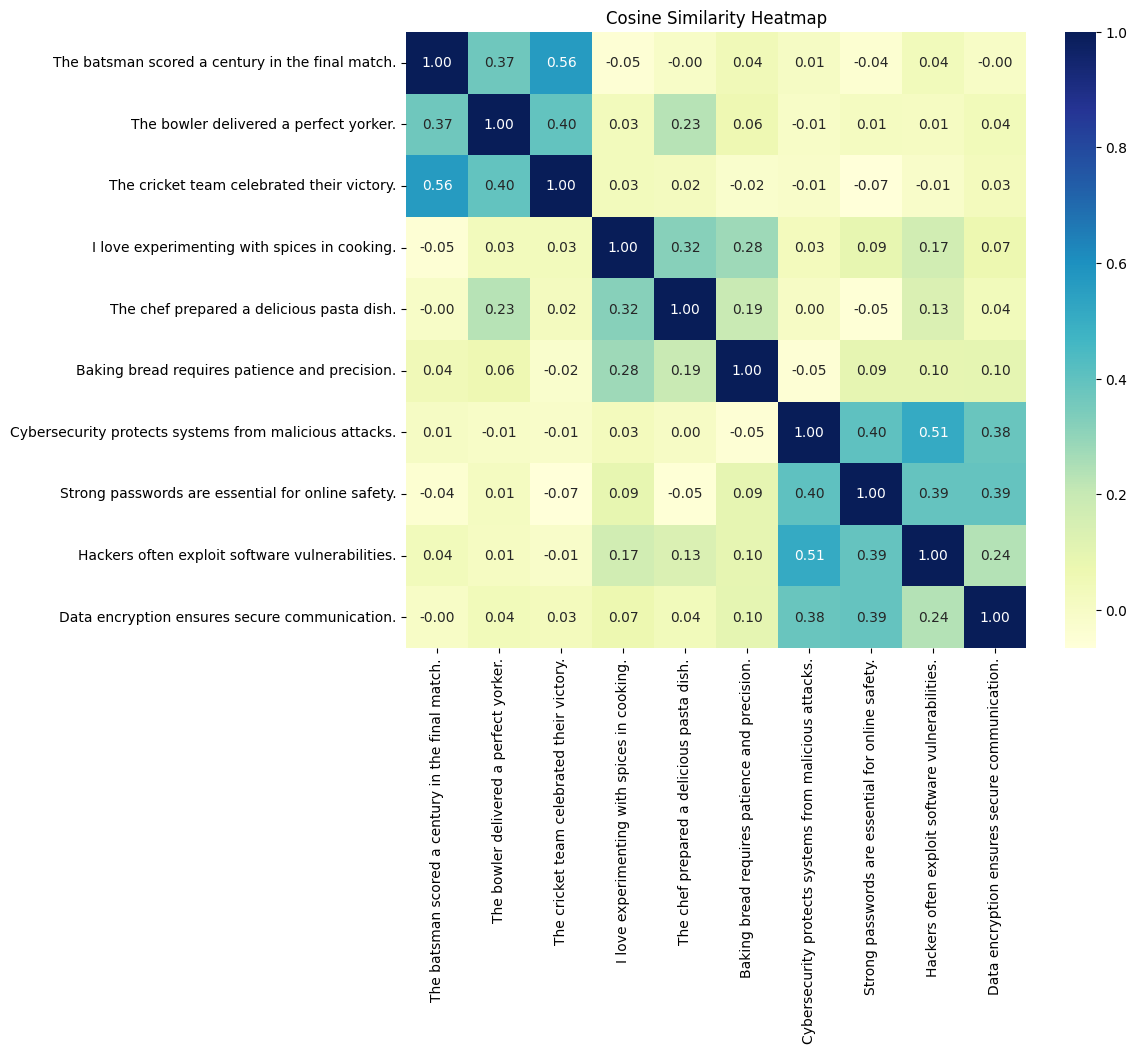

In [ ]:
similarity_matrix = util.cos_sim(embeddings, embeddings).cpu().numpy()

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, xticklabels=sentences, yticklabels=sentences, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Cosine Similarity Heatmap")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

cosine_scores = util.cos_sim(query_embedding, embeddings)[0]

# Get top 2 most similar sentences
top_results = np.argsort(-cosine_scores)[:2]
for idx in top_results:
    print(f"Sentence: {sentences[idx]} | Similarity: {cosine_scores[idx]:.4f}")

Sentence: The batsman scored a century in the final match. | Similarity: 0.5679
Sentence: The bowler delivered a perfect yorker. | Similarity: 0.5464
